# Exercise 07 - Image Stitching using Feature Matching

**Objective:** Create a basic panorama by detecting/matching features and aligning overlapping images using Homography.

This notebook is designed to run directly in **Google Colab**. Run cells from top to bottom.

In [1]:
# Common setup for Google Colab
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)

def show_bgr(img, title="Image", size=(8, 5)):
    """Display a BGR/OpenCV image correctly in notebook."""
    plt.figure(figsize=size)
    if img.ndim == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_gray(img, title="Image", size=(8, 5)):
    plt.figure(figsize=size)
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

print("OpenCV version:", cv2.__version__)

OpenCV version: 4.13.0


## Step 1: Create overlapping images
A wide synthetic scene is created, then two overlapping crops are taken from it.

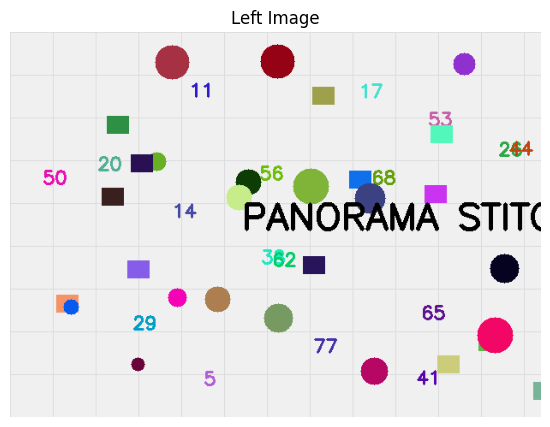

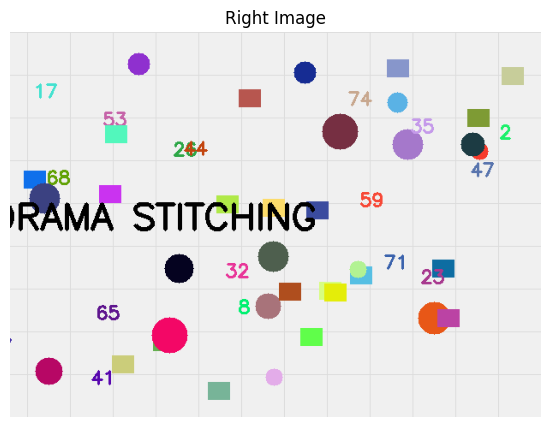

In [2]:

# Create a wide scene with many details
scene = np.full((450, 1000, 3), 240, dtype=np.uint8)

# background pattern
for x in range(0, 1000, 50):
    cv2.line(scene, (x, 0), (x, 450), (220, 220, 220), 1)
for y in range(0, 450, 50):
    cv2.line(scene, (0, y), (1000, y), (220, 220, 220), 1)

# add unique features
rng = np.random.default_rng(21)
for i in range(80):
    x, y = rng.integers([30, 30], [970, 420])
    color = tuple(int(c) for c in rng.integers(0, 255, size=3))
    if i % 3 == 0:
        cv2.circle(scene, (int(x), int(y)), int(rng.integers(8, 22)), color, -1)
    elif i % 3 == 1:
        cv2.rectangle(scene, (int(x), int(y)), (int(x+25), int(y+20)), color, -1)
    else:
        cv2.putText(scene, str(i), (int(x), int(y)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

cv2.putText(scene, "PANORAMA STITCHING", (270, 230), cv2.FONT_HERSHEY_SIMPLEX, 1.4, (0,0,0), 4)

# Two overlapping images
left_img = scene[:, 0:620].copy()
right_img = scene[:, 380:1000].copy()

show_bgr(left_img, "Left Image")
show_bgr(right_img, "Right Image")


## Step 2: Detect ORB features and match them
Feature matching finds common points in the overlapping area.

Keypoints left: 1805
Keypoints right: 1806
Total matches: 678


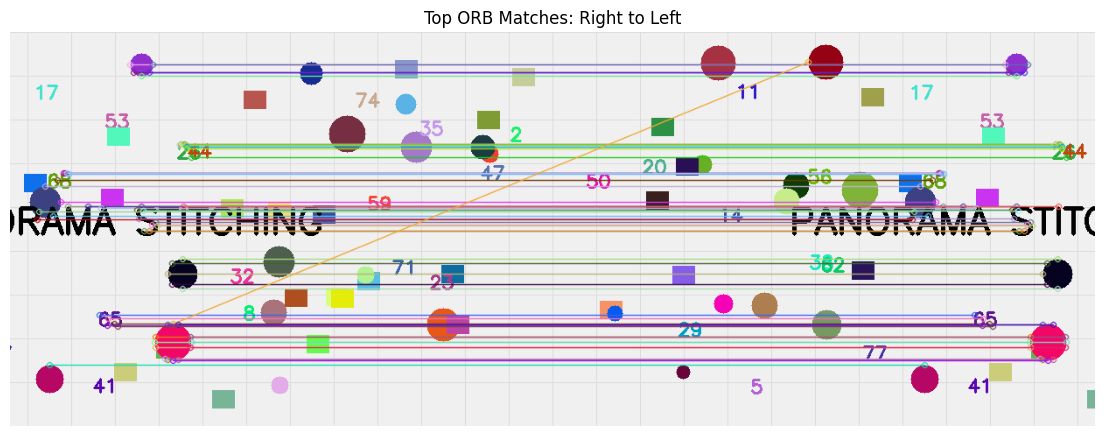

In [3]:

gray_left = cv2.cvtColor(left_img, cv2.COLOR_BGR2GRAY)
gray_right = cv2.cvtColor(right_img, cv2.COLOR_BGR2GRAY)

orb = cv2.ORB_create(nfeatures=2000)
kp_left, des_left = orb.detectAndCompute(gray_left, None)
kp_right, des_right = orb.detectAndCompute(gray_right, None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des_right, des_left)  # right -> left
matches = sorted(matches, key=lambda m: m.distance)

print("Keypoints left:", len(kp_left))
print("Keypoints right:", len(kp_right))
print("Total matches:", len(matches))

match_preview = cv2.drawMatches(
    right_img, kp_right, left_img, kp_left, matches[:60], None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)
show_bgr(match_preview, "Top ORB Matches: Right to Left", size=(14, 7))


## Step 3: Compute Homography using RANSAC
Homography aligns the right image to the coordinate space of the left image.

In [4]:

if len(matches) < 10:
    raise RuntimeError("Not enough matches for stitching.")

good_matches = matches[:120]

src_pts = np.float32([kp_right[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
dst_pts = np.float32([kp_left[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 4.0)
print("Homography:\n", H)
print("Inliers:", int(mask.sum()), "/", len(good_matches))


Homography:
 [[ 1.00265474e+00 -8.21571627e-06  3.80152179e+02]
 [ 1.08492563e-03  1.00083376e+00 -1.69632360e-01]
 [ 4.60054042e-06  4.44342770e-07  1.00000000e+00]]
Inliers: 118 / 120


## Step 4: Warp and blend images into a panorama

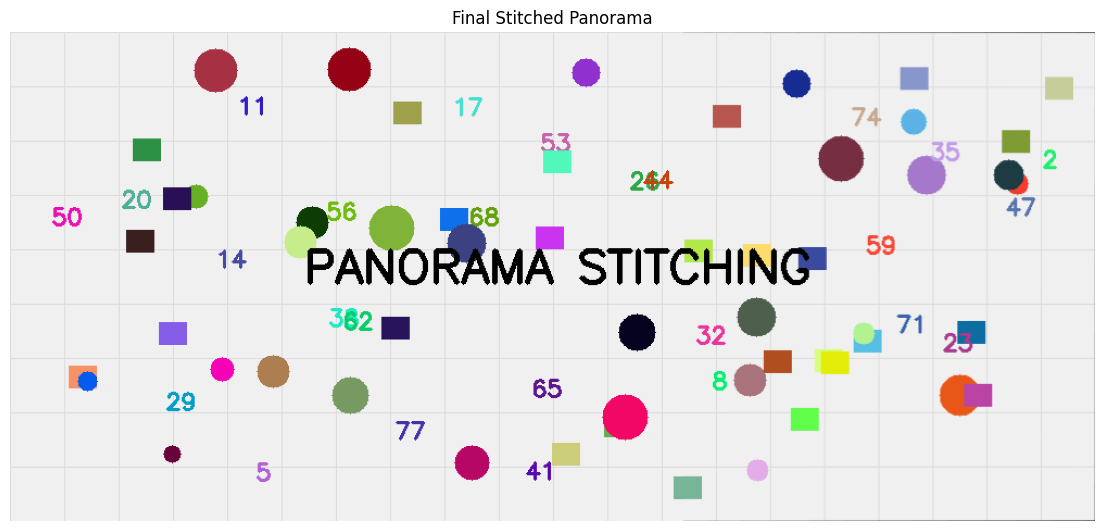

In [5]:

def stitch_pair(left, right, H):
    h1, w1 = left.shape[:2]
    h2, w2 = right.shape[:2]

    corners_right = np.float32([[0,0], [0,h2], [w2,h2], [w2,0]]).reshape(-1,1,2)
    corners_right_transformed = cv2.perspectiveTransform(corners_right, H)
    corners_left = np.float32([[0,0], [0,h1], [w1,h1], [w1,0]]).reshape(-1,1,2)

    all_corners = np.concatenate((corners_left, corners_right_transformed), axis=0)
    [xmin, ymin] = np.int32(all_corners.min(axis=0).ravel() - 0.5)
    [xmax, ymax] = np.int32(all_corners.max(axis=0).ravel() + 0.5)

    translation = [-xmin, -ymin]
    T = np.array([[1, 0, translation[0]], [0, 1, translation[1]], [0, 0, 1]])

    panorama = cv2.warpPerspective(right, T @ H, (xmax - xmin, ymax - ymin))

    # Place left image
    x_offset, y_offset = translation
    panorama[y_offset:y_offset+h1, x_offset:x_offset+w1] = left

    return panorama

panorama = stitch_pair(left_img, right_img, H)
show_bgr(panorama, "Final Stitched Panorama", size=(14, 7))


## Result
The two overlapping images were matched using ORB, aligned using Homography, and merged into a panorama.